In [3]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[autoreload of causaldynamics.baselines.ode_discovery_agl failed: Traceback (most recent call last):
  File "/network/scratch/j/julien.boussard/CausalDynamics/env_causaldyn/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 276, in check
    superreload(m, reload, self.old_objects)
  File "/network/scratch/j/julien.boussard/CausalDynamics/env_causaldyn/lib/python3.10/site-packages/IPython/extensions/autoreload.py", line 475, in superreload
    module = reload(module)
  File "/cvmfs/ai.mila.quebec/apps/arch/distro/python/3.10/lib/python3.10/importlib/__init__.py", line 159, in reload
    raise ImportError(msg.format(parent_name),
ImportError: parent 'causaldynamics.baselines' not in sys.modules
]


In [4]:
import copy
import numpy as np
import xarray as xr
import glob 

from causaldynamics.scm import create_scm_graph
from causaldynamics.plot import plot_scm
from causaldynamics.score import score
from causaldynamics.baselines import PCMCIPlus
from causaldynamics.baselines import FPCMCI
from causaldynamics.baselines import DYNOTEARS
from causaldynamics.baselines import VARLiNGAM
from causaldynamics.baselines import NGC_LSTM
from causaldynamics.baselines import TSCI
from causaldynamics.baselines import CUTSPlus
# from causaldynamics.baselines import RCD
# from causaldynamics.baselines import GIN
# from causaldynamics.baselines import GRASP
from causaldynamics.baselines import TCDF

# DYNOTEARS / FPCMCI + not sure about PCMCIPlus + VARLiNGAM

from tqdm import tqdm
from pathlib import Path
import torch

import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt 

from causaldynamics.baselines import PICABU, StructuredLowRankDiscovery, StructuredODEDiscovery

In [5]:
# import glob 

# all_files = glob.glob("../data/simple/noise=2.00_confounder=True/data/*")
# # for file in all_files:
# #     print(file.split("/")[-1])
# len(all_files)

In [38]:
# Once you have the dataset, either generated or downloaded
# Notice that the dataset has `time_series` and `adjacency_matrix` variables.
DATA_DIR = Path("../data/simple/noise=0.00_confounder=False/data")  # (you can change this to your own path)
ds = xr.open_dataset(DATA_DIR / "Lorenz84_N10_T1000.nc")

# DATA_DIR = Path("../data/simple/noise=0.00_confounder=False/data")  # (you can change this to your own path)
# ds = xr.open_dataset(DATA_DIR / "Rossler_N10_T1000.nc")

# # Extract timeseries and adjacency matrix as target # If not coupled
# timeseries = ds['time_series'].to_numpy().transpose(1, 0, 2) # shape of (N, T, D)
# adj_matrix = ds['adjacency_matrix'].to_numpy()

# # DATA_DIR = Path("../data/coupled/coupling=linear_noise=0.00_systems=3_confounder=False_standardize=False_timelag=0_activation=none/data")  # (you can change this to your own path)
# DATA_DIR = Path("../data/coupled/coupling=periodic_noise=0.00_systems=10_confounder=False_standardize=False_timelag=0_activation=mixed/data")  # (you can change this to your own path)
# ds = xr.open_dataset(DATA_DIR / "SROSSLER_N10_T1000_seed2.nc")

DATA_DIR = Path("../data/climate/coupled_atmos_ocean/data")  # (you can change this to your own path)
ds = xr.open_dataset(DATA_DIR / "ESM_N10_T1000.nc")
adj_matrix = ds['adjacency_matrix'].to_numpy() ## `adjacency_matrix_summary` is the true adjacency matrix for coupled system

timeseries = ds['time_series'].to_numpy() #[..., 0].transpose(1, 0, 2) # shape of (N, T, D)
adj_matrix = ds['adjacency_matrix'].to_numpy()


# # SLORENZ_N10_T1000_seed0 ok
# # SROSSLER_N10_T1000_seed2 ok
# # SRANDOM_N10_T1000_seed1 ~~
# # SRAYLEIGHBENARD_N10_T1000_seed0 ~~

# # NOTE: If dataset is from coupled system e.g., "../data/coupled/...", follow these changes to load the data:
# timeseries = ds['time_series'].to_numpy()[..., 0].transpose(1, 0, 2) ## select the first dimension of each multidimensional node
# adj_matrix = ds['adjacency_matrix_summary'].to_numpy() ## `adjacency_matrix_summary` is the true adjacency matrix for coupled system

n_systems = adj_matrix.shape[0]

In [39]:
adj_matrix

array([[1., 1., 1., 0.],
       [1., 1., 1., 1.],
       [1., 1., 1., 0.],
       [0., 1., 1., 1.]], dtype=float32)

In [40]:
timeseries.shape

(1000, 10, 4, 374)

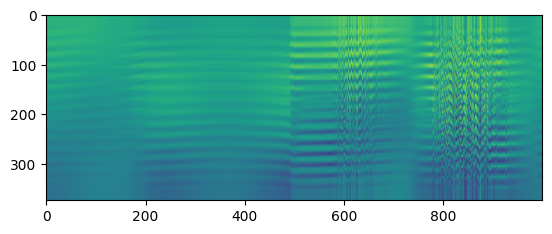

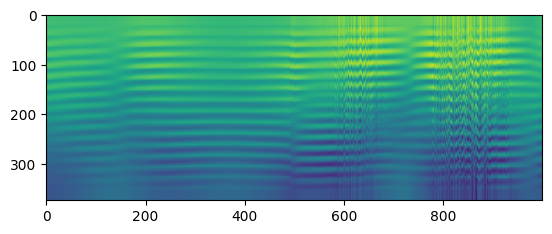

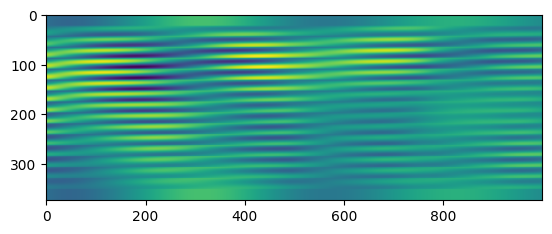

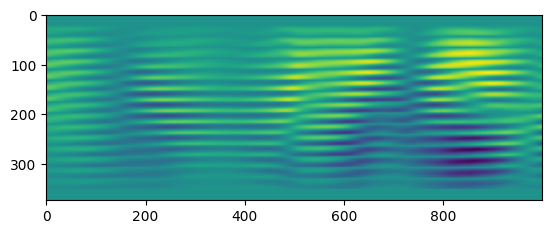

In [43]:
for k in range(4):
    plt.imshow(timeseries[:, 0, k].T)
    plt.show()
    plt.close()

In [8]:
# glob.glob("../data/coupled/coupling=linear_noise=0.00_systems=3_confounder=False_standardize=False_timelag=0_activation=mixed/data/*")

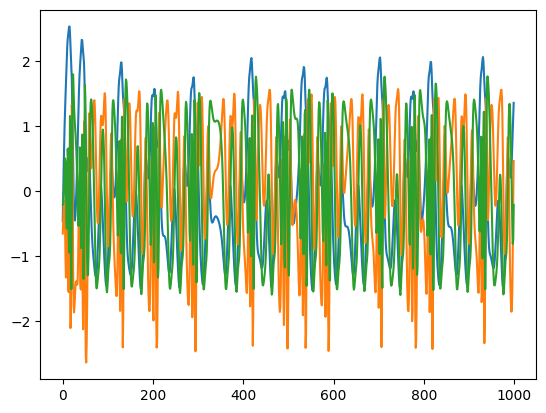

In [ ]:
for k in range(1):
    
    # timeseries_norm = timeseries[k]
    # timeseries_norm -= timeseries_norm.mean(0)
    # timeseries_norm /= timeseries_norm.std(0)
    
    plt.figure()
    for j in range(3):
        plt.plot(timeseries[:, j])
    plt.show()
    plt.close()
    
#     plt.figure()
#     for j in range(3):
#         plt.plot(np.diff(timeseries_norm[:, j]))
#     plt.show()
#     plt.close()


In [10]:
# RESULTS_DIR = Path("../data/simple/noise=0.00_confounder=False/eval/tcdf")  # (you can change this to your own path)
# ds = xr.open_dataset(DATA_DIR / "Rossler_N10_T1000.nc")


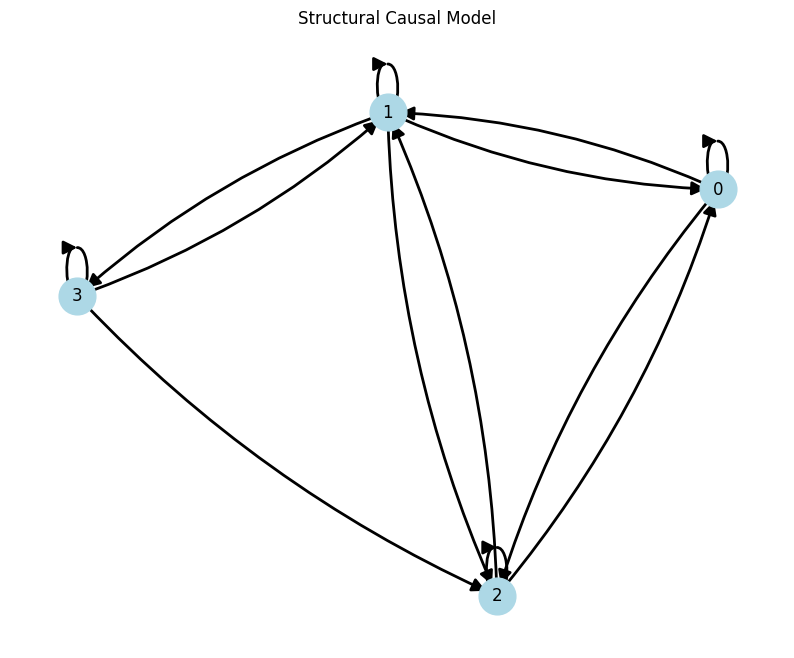

In [32]:
G = create_scm_graph(adj_matrix)
plot_scm(G);


In [12]:
# tau = 0
# T = timeseries.shape[1]
# D = timeseries.shape[-1]
# timeseries_stacked = np.stack([np.stack([timeseries[k, i:i + tau + 1] for i in range(T - tau)]) for k in range(timeseries.shape[0])])
# timeseries_stacked.shape

timeseries_stacked = timeseries[:, :, None]

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [18]:
timeseries_stacked.shape

(10, 1000, 1, 3)

In [ ]:
tau_max = 1 # i.e. no delay 

## Estimate adjacency matrix
lowrank_adj_matrix = []

all_shd = []
all_auroc = []
all_auprc = []

# 0.01, 0.025, 0.05, 0.075, 
lambda_m_hp  = 0.1
# for lambda_m_hp in [0.5, 0.75, 1]:
for i in range(1):
    for x in timeseries_stacked[0:1, :200]:
        lowrank_model = StructuredODEDiscovery(
            coupled=False,
            t = tau_max,
            n = n_systems,
            L_lipschitz = 1, 
            is_lipschitz = False,
            hidden_dim = 8, 
            n_layers = 2,
            device = device,
            beta_init = 0.33, 
            beta_min = 0.33,
            annealing_rate = 0.95,
            annealing_epochs = 10,
            normalize_grad = True,
        )
        trained_model, mask = lowrank_model.run(n_samples=3, lambda_grad=100, X=torch.tensor(x).to(device), l0_l1_l2='l0', th=0.5, lr=0.001, lambda_m = lambda_m_hp, n_inner_min_sparse = 100, batch_size=128, n_inner=4_000, patience = 200, save_fig_path="l0_lorenz84_loss.png")
        lowrank_adj_matrix.append(mask.detach().cpu().numpy())
        #     lowrank_S_matrix.append(copy.deepcopy(lowrank_model.model.S))

    #     coupled = False # True when doing adj matrix summary ---

    #     mask_numpy = mask.detach().cpu().numpy()

    #     if coupled:
    #         vec = (mask_numpy > 0.5).sum(1) == 0
    #         if np.any(vec):
    #             idx = np.flatnonzero(vec)
    #             mask_numpy[0, idx, idx] = 1

    #     results_scores = score(
    #         preds= mask_numpy, #.transpose((0, 2, 1)), # Need to transpos
    #         labs= adj_matrix,
    #         name='LR_discovery'
    #     )

    #     print(results_scores)

    results_scores = score(
        preds= np.array(lowrank_adj_matrix)[:, 0], #.transpose((0, 2, 1)), # Need to transpose
        labs= adj_matrix,
        name='LR_discovery'
    )


    print(results_scores)
    print(lowrank_adj_matrix)

#         all_shd.append(results_scores.loc["Joint SHD", "LR_discovery"])
#         all_auroc.append(results_scores.loc["Joint AUROC", "LR_discovery"])
#         all_auprc.append(results_scores.loc["Joint AUPRC", "LR_discovery"])
    
# print(f"Hyperparam {lambda_m_hp} AUROC {results_scores.loc['Joint AUROC', 'LR_discovery']}")


Dimensions: N=3, T=1
Number of NaN values in X: False
Number of NaN values after normalization in X: False
Constant dimensions in X: (tensor([], device='cuda:0', dtype=torch.int64),)
X_t_all.shape: torch.Size([199, 1, 3])
X_last_all.shape: torch.Size([199, 1, 3])
  → stopping inner loop at step 545 after 200 no-improve steps (best=1.183471, current=1.253699)
recon=0.9998  |M|_1=8.480  grad_penalty=0.0016  
Scoring...
                  LR_discovery
Metric                        
Joint AUROC           0.500000
Individual AUROC      0.500000
Null AUROC            0.500000
Joint AUPRC           0.666667
Individual AUPRC      0.666667
Null AUPRC            0.666667
Joint SHD             3.000000
[array([[[0.880797, 0.880797, 0.880797],
        [0.880797, 0.880797, 0.880797],
        [0.880797, 0.880797, 0.880797]]], dtype=float32)]


In [16]:
# Make proper script for hyperparam search and iterate multiple times 
adj_matrix

array([[1, 1, 1],
       [0, 0, 1],
       [1, 1, 0]])

In [61]:
# Newer params 

Hyperparam 0.01 AUROC 0.71 / AUPRC 0.81
Hyperparam 0.02 AUROC 0.69 / AUPRC 0.82
Hyperparam 0.025 AUROC 0.61 / AUPRC 0.82
Hyperparam 0.03 AUROC 0.72 / AUPRC 0.90
Hyperparam 0.04 AUROC 0.68 / AUPRC 0.82
Hyperparam 0.05 AUROC 0.64 / AUPRC 0.79
Hyperparam 0.1 AUROC 0.69 / AUPRC 0.83
Hyperparam 0.125 AUROC 0. / AUPRC 0.
Hyperparam 0.15 AUROC 0.76 / AUPRC 0.89
Hyperparam 0.175 AUROC 0.72 / AUPRC 0.85
Hyperparam 0.2 AUROC 0.72 / AUPRC 0.84
Hyperparam 0.25 AUROC 0.57 / AUPRC 0.72
Hyperparam 0.3 AUROC 0.69 / AUPRC 0.83
Hyperparam 0.5 AUROC 0.70 / AUPRC 0.82


SyntaxError: invalid syntax (2695532812.py, line 3)

In [ ]:
# Older params 

Hyperparam 0.01 AUROC 0.69 / AUPRC 0.846
Hyperparam 0.025 AUROC 0.66 / AUPRC 0.815
Hyperparam 0.05 AUROC 0.7294444444444445 / AUPRC 0.874877
Hyperparam 0.075 AUROC 0.714861 / AUPRC 0.850685
Hyperparam 0.1 AUROC 0.679444 / AUPRC 0.836102
Hyperparam 0.25 AUROC 0.683 / AUPRC 0.824406
Hyperparam 0.5 AUROC 0.733 / AUPRC 0.871514
Hyperparam 0.75 AUROC 0.707 / AUPRC 0.85
# Hyperparam 1. AUROC 0. / AUPRC 0.


# 0.01 --> not much sparsification...
# 0.1 --> still not enough \but 0.94 / 0.98
# 1 --> too high
# Start already with 0.33
# n inner min sparse? better
# larger net? 

In [47]:
mask.detach().cpu().numpy()

array([[[0.86157906, 0.8698701 , 0.86762345],
        [0.86209327, 0.82749104, 0.8683462 ],
        [0.8674016 , 0.85893226, 0.8346015 ]]], dtype=float32)

In [48]:
adj_matrix

array([[1, 1, 1],
       [0, 0, 1],
       [1, 1, 0]])

In [19]:
results_scores = score(
    preds= np.array(lowrank_adj_matrix)[:, 0], #.transpose((0, 2, 1)), # Need to transpose
    labs= ds['adjacency_matrix_summary'].to_numpy(),
    name='LR_discovery'
)

results_scores

Scoring...


,LR_discovery
Metric,
Joint AUROC,0.511667
Individual AUROC,0.550000
Null AUROC,0.500000
Joint AUPRC,0.400681
Individual AUPRC,0.488056
Null AUPRC,0.333333
Joint SHD,28.000000


In [26]:
results_scores.loc["Joint SHD", "LR_discovery"]
# results_dict["joint_auroc"] = results_scores.loc["Joint AUROC", model_name]
# results_dict["joint_auprc"] = results_scores.loc["Joint AUPRC", model_name]


4.0

In [29]:
coupled = True


mask_numpy = mask.detach().cpu().numpy()

if coupled:
    vec = (mask_numpy > 0.1).sum(1) == 0
    if np.any(vec):
        idx = np.flatnonzero(vec)
        mask_numpy[0, idx, idx] = 1


results_scores = score(
    preds= mask_numpy, #.transpose((0, 2, 1)), # Need to transpos
    labs= adj_matrix,
    name='LR_discovery'
)

results_scores


Scoring...


,LR_discovery
Metric,
Joint AUROC,0.555556
Individual AUROC,0.555556
Null AUROC,0.500000
Joint AUPRC,0.500000
Individual AUPRC,0.500000
Null AUPRC,0.333333
Joint SHD,4.000000


In [276]:
# gradient regularization --> seems to help
# Random vs constant initialization --> Not a big deal 
# different LR? --> careful if too high. We want to start sparsifying before we converged. However seems to help 
# betas --> to avoid getting stuck, decrease betas for gate parameters 
# More samples? --> Probably, but slows down training
# Size of the neural net --> Narrow seems better (8 > 32); deep --> maybe not worse but slower
# Increase patience --> leads to more sparse 

In [212]:
adj_matrix

array([[0, 0, 0],
       [1, 0, 0],
       [0, 1, 1]])

In [112]:
lowrank_adj_matrix

[array([[[0.9451839 , 0.9423695 , 0.8819076 ],
         [0.6137518 , 0.8584088 , 0.89564717],
         [0.89744174, 0.9373828 , 0.94890845]]], dtype=float32)]

In [85]:
mask_numpy = mask.detach().cpu().numpy()

vec = (mask_numpy > 0.5).sum(1) == 0
if np.any(vec):
    idx = np.flatnonzero(vec)
    mask_numpy[0, idx, idx] = 1


In [84]:
mask_numpy

array([[[1.        , 0.2869474 , 0.6877344 ],
        [0.13704191, 1.        , 0.09842564],
        [0.46730036, 0.01329406, 0.7065126 ]]], dtype=float32)

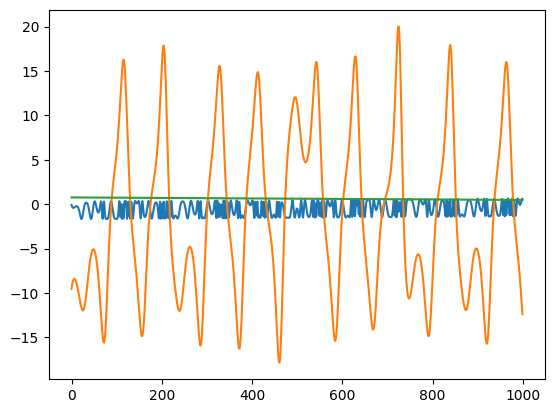

In [18]:
plt.figure()
for j in range(3):
    plt.plot(timeseries[3, :, j])
plt.show()
plt.close()


In [29]:
adj_matrix

array([[0., 0., 0.],
       [1., 1., 0.],
       [1., 0., 1.]], dtype=float32)

In [86]:
results_scores = score(
    preds= mask.detach().cpu().numpy(), #.transpose((0, 2, 1)), # Need to transpos
    labs= adj_matrix,
    name='LR_discovery'
)

results_scores

Scoring...


,LR_discovery
Metric,
Joint AUROC,0.833333
Individual AUROC,0.833333
Null AUROC,0.500000
Joint AUPRC,0.944444
Individual AUPRC,0.944444
Null AUPRC,0.666667
Joint SHD,4.000000


In [19]:
# If all 1s, need to replace with 1 AUROC
# Or maybe it is 1s because 2x2 
# Ok for Lorenz, then store matrix and compute score later

In [ ]:
results_dict = {}
results_dict["joint_shd"] = results_scores.loc["Joint SHD", "LR_discovery"]
results_dict["joint_auroc"] = results_scores.loc["Joint AUROC", "LR_discovery"]
results_dict["joint_auprc"] = results_scores.loc["Joint AUPRC", "LR_discovery"]
results_dict["any_nans"] = np.any(np.isnan(timeseries_stacked))





In [ ]:
results_dict

In [112]:
results_scores.loc["Joint SHD", "LR_discovery"]
np.savez('results_test.npz', **results_dict)



In [116]:
np.any(np.isnan(timeseries_stacked))

False

In [71]:
adj_matrix

array([[1, 1],
       [1, 1]])

In [18]:
tau_max = 1 # i.e. one delay only
# no instantaneous? 

## Estimate adjacency matrix
lowrank_adj_matrix = []
lowrank_S_matrix = []

for x in [timeseries_stacked[0]]:
    lowrank_model = StructuredLowRankDiscovery(
        k = 1,
        n = 3,
        L_lipschitz = 1, 
        is_lipschitz = False,
        hidden_dim = 32, n_layers = 3,
        t = tau_max,
        device = device,
    )
    trained_model, mask = lowrank_model.run(X=torch.tensor(x).to(device), l0_l1_l2='l0', th=0.5, lr=0.001, lambda_s = 0.0, lambda_grad=100, lambda_m = 0.001, n_outer = 1, n_inner_min_sparse = 100, batch_size=32, n_inner=4_000, patience = 500)
    lowrank_adj_matrix.append(mask.detach().cpu().numpy())
    
#     lowrank_S_matrix.append(copy.deepcopy(lowrank_model.model.S))



Dimensions: N=3, K=1, T=1
Number of NaN values in X: 0
Number of NaN values after normalization in X: 0
Constant dimensions in X: (array([], dtype=int64),)
outer=01  h(W)=0.00000  recon=0.0000  entropy=0.000  |W|_1=0.000  |M|_1=5.998  lambda=0.000  mu=0.00
M_mask tensor([[0., 1., 1.],
        [1., 0., 1.],
        [1., 0., 1.]], device='cuda:0')


In [23]:
np.array(lowrank_adj_matrix)[:, 0]

array([[[0., 1., 1.],
        [1., 0., 1.],
        [1., 0., 1.]]], dtype=float32)

In [24]:
adj_matrix

array([[0, 1, 1],
       [1, 1, 0],
       [1, 0, 1]])

In [20]:
score(
    preds= (np.array(lowrank_adj_matrix)[:, 0]), #.transpose((0, 2, 1)), # Need to transpos
    labs= adj_matrix,
    name='LR_discovery'
)


Scoring...


,LR_discovery
Metric,
Joint AUROC,0.750000
Individual AUROC,0.750000
Null AUROC,0.500000
Joint AUPRC,0.805556
Individual AUPRC,0.805556
Null AUPRC,0.666667
Joint SHD,2.000000


In [30]:
# M[:, :, i] is driver of dimension i
mask[0]

tensor([[0.9856, 0.9854, 0.9850],
        [0.9868, 0.9841, 0.9852],
        [0.9730, 0.9831, 0.9792]], device='cuda:0', grad_fn=<SelectBackward0>)

In [31]:
adj_matrix

array([[1, 1, 0],
       [1, 1, 1],
       [1, 1, 1]])

In [15]:
mask[0].sum(), adj_matrix.sum()

(tensor(4., device='cuda:0'), 8)

In [16]:
mask

tensor([[[1., 1., 0.],
         [1., 1., 0.],
         [0., 0., 0.]],

        [[0., 0., 0.],
         [0., 0., 0.],
         [0., 0., 0.]]], device='cuda:0')

In [81]:
np.array(lowrank_adj_matrix).shape

(1, 2, 10, 10)

In [130]:
## Compute scores
score(
    preds= np.array(lowrank_adj_matrix)[:, 0], #.transpose((0, 2, 1)), # Need to transpos
    labs= adj_matrix,
    name='LR_discovery'
)



Scoring...


,LR_discovery
Metric,
Joint AUROC,0.497508
Individual AUROC,0.497508
Null AUROC,0.500000
Joint AUPRC,0.139409
Individual AUPRC,0.139409
Null AUPRC,0.140000
Joint SHD,35.000000


# Evaluate baseline 

In [49]:
## Estimate adjacency matrix
tau_max = 1

from causaldynamics.baselines import PCMCIPlus, FPCMCI, VARLiNGAM, DYNOTEARS, NGC_LSTM, TSCI, CUTSPlus


# timeseries = ds['time_series'].to_numpy().transpose(1, 0, 2) # shape of (N, T, D)
# adj_matrix = ds['adjacency_matrix'].to_numpy()

clstm_adj_matrix = []
for x in tqdm(timeseries):
    clstm_model = NGC_LSTM(tau_max=tau_max)
    clstm_model.run(X=x)
    clstm_adj_matrix.append(copy.deepcopy(clstm_model.adj_matrix))



100%|██████████| 10/10 [00:07<00:00,  1.35it/s]


In [50]:
## Compute scores
score(
    preds= np.array(clstm_adj_matrix),
    labs= adj_matrix,
    name='cLSTM'
)


Scoring...


,cLSTM
Metric,
Joint AUROC,0.500000
Individual AUROC,0.500000
Null AUROC,0.500000
Joint AUPRC,0.666667
Individual AUPRC,0.666667
Null AUPRC,0.666667
Joint SHD,30.000000
